### Stage 2

In [20]:
# Download data
print("Starting data download...")
def download_data(save_folder, base_raw_url, files_to_download):
    import os
    import urllib.request

    os.makedirs(save_folder, exist_ok=True)

    for file_name in files_to_download:
        raw_url = base_raw_url + file_name
        save_path = os.path.join(save_folder, file_name)

        # check if file already exists
        if os.path.exists(save_path):
            print(f"{file_name} already exists. Skipping download.")
            continue
        print(f"Downloading {file_name}...")
        try:
            urllib.request.urlretrieve(raw_url, save_path)
            print(f"Successfully saved to: {save_path}\n")
        except Exception as e:
            print(f"Failed to download {file_name}. Error: {e}\n")
base_raw_url = "https://raw.githubusercontent.com/CRLala/NLPLabs-2024/main/Dont_Patronize_Me_Trainingset/"

files_to_download = [
    "dontpatronizeme_pcl.tsv",
]

save_folder = "Dont_Patronize_Me_Data"

download_data(save_folder, base_raw_url, files_to_download)

# CSVs (FIXED: use raw.githubusercontent.com + URL-encoded space)
base_raw_url = (
    "https://raw.githubusercontent.com/"
    "Perez-AlmendrosC/dontpatronizeme/master/"
    "semeval-2022/practice%20splits/"
)

download_data(save_folder, base_raw_url, [
    "dev_semeval_parids-labels.csv",
    "train_semeval_parids-labels.csv"
])

print("All downloads complete!")

Starting data download...
dontpatronizeme_pcl.tsv already exists. Skipping download.
dev_semeval_parids-labels.csv already exists. Skipping download.
train_semeval_parids-labels.csv already exists. Skipping download.
All downloads complete!


In [2]:
# Process .tsv files

# -- dontpatronizeme_pcl.tsv contains paragraphs annotated with a label from 0 (not containing PCL) to 4 (being highly patronizing or condescending) towards vulnerable communities.
# It contains one instance per line with the following format:

# 	- <par_id> <tab> <art_id> <tab> <keyword> <tab> <country_code> <tab> <text> <tab> <label>

	# where
	# - <par_id> is a unique id for each one of the paragraphs in the corpus.
	# - <art_id> is the document id in the original NOW corpus (News on Web: https://www.english-corpora.org/now/).
	# - <keyword> is the search term used to retrieve texts about a target community.
	# - <country_code> is a two-letter ISO Alpha-2 country code for the source media outlet.
	# - <text> is the paragraph containing the keyword.
	# - <label> is an integer between 0 and 4. Each paragraph has been annotated by two annotators as 0 (No PCL), 1 (borderline PCL) and 2 (contains PCL). The combined annotations have been used in the following graded scale:


import pandas as pd
import os

def load_pcl_data(file_path):
    # Column names based on the structure you provided
    # Note: You mentioned <par_id> <art_id> <keyword> <country_code> <text> <label>
    columns = ['par_id', 'art_id', 'keyword', 'country_code', 'text', 'label']

    # We use sep='\t' for tab-separated files.
    # 'on_bad_lines' is set to skip to avoid errors if the README headers are still in the file.
    # 'quoting=3' (QUOTE_NONE) is often needed if the text contains unescaped quotes.
    df = pd.read_csv(
        file_path,
        sep='\t',
        skiprows=4, # The DPM dataset usually has 4 rows of info text at the top
        names=columns,
        index_col=False,
        on_bad_lines='skip'
    )

    # Clean up: Drop rows where the label or text is missing
    df = df.dropna(subset=['text', 'label'])

    # Convert label to integer (sometimes read as float)
    df['label'] = df['label'].astype(int)

    return df

# --- Usage ---
pcl_path = os.path.join(save_folder, "dontpatronizeme_pcl.tsv")
df_pcl = load_pcl_data(pcl_path)

print(f"Loaded {len(df_pcl)} rows.")
print(df_pcl[['par_id', 'text', 'label']].head())



Loaded 10468 rows.
   par_id                                               text  label
0       1  We 're living in times of absolute insanity , ...      0
1       2  In Libya today , there are countless number of...      0
2       3  White House press secretary Sean Spicer said t...      0
3       4  Council customers only signs would be displaye...      0
4       5  " Just like we received migrants fleeing El Sa...      0


In [3]:
# Process split files data



import pandas as pd

import os



# Define paths (assuming they are in the folder we created earlier)

train_path = os.path.join("Dont_Patronize_Me_Data", "train_semeval_parids-labels.csv")
dev_path = os.path.join("Dont_Patronize_Me_Data", "dev_semeval_parids-labels.csv")



# Load the CSVs

# Note: If these files don't have a header row, use header=None and names=['par_id', 'label']

df_train_ids = pd.read_csv(train_path)
print(df_train_ids.head()) # Check the structure of the loaded DataFrame
df_dev_ids = pd.read_csv(dev_path)
print(df_dev_ids.head()) # Check the structure of the loaded DataFrame



# Extract par_id column into Python lists

# We use .astype(str) to ensure IDs are strings,

# which helps when matching against the main .tsv file later.

train_par_ids = df_train_ids['par_id'].astype(str).tolist()
dev_par_ids = df_dev_ids['par_id'].astype(str).tolist()

# Verification
print(f"Extracted {len(train_par_ids)} IDs for Training.")
print(f"Extracted {len(dev_par_ids)} IDs for Development/Validation.")
print(f"First 5 Train IDs: {train_par_ids[:5]}")

   par_id                  label
0    4341  [1, 0, 0, 1, 0, 0, 0]
1    4136  [0, 1, 0, 0, 0, 0, 0]
2   10352  [1, 0, 0, 0, 0, 1, 0]
3    8279  [0, 0, 0, 1, 0, 0, 0]
4    1164  [1, 0, 0, 1, 1, 1, 0]
   par_id                  label
0    4046  [1, 0, 0, 1, 0, 0, 0]
1    1279  [0, 1, 0, 0, 0, 0, 0]
2    8330  [0, 0, 1, 0, 0, 0, 0]
3    4063  [1, 0, 0, 1, 1, 1, 0]
4    4089  [1, 0, 0, 0, 0, 0, 0]
Extracted 8375 IDs for Training.
Extracted 2094 IDs for Development/Validation.
First 5 Train IDs: ['4341', '4136', '10352', '8279', '1164']


In [4]:
# 1. Ensure the ID column in the main dataframe is a string to match our lists
df_pcl['par_id'] = df_pcl['par_id'].astype(str)

# 2. Use .isin() to filter the master dataframe
# We use .copy() to avoid SettingWithCopyWarnings later during preprocessing
train_set = df_pcl[df_pcl['par_id'].isin(train_par_ids)].copy()
dev_set = df_pcl[df_pcl['par_id'].isin(dev_par_ids)].copy()

# 3. Create Binary Labels (Subtask 1)
# Labels 0 and 1 -> 0 (Not PCL)
# Labels 2, 3, and 4 -> 1 (PCL)
train_set['label_binary'] = train_set['label'].apply(lambda x: 1 if x >= 2 else 0)
dev_set['label_binary'] = dev_set['label'].apply(lambda x: 1 if x >= 2 else 0)

# 4. Final Verification
print(f"Final Train Set: {train_set.shape[0]} rows")
print(f"Final Dev Set: {dev_set.shape[0]} rows")

print("\nTrain Class Distribution (Binary):")
print(train_set['label_binary'].value_counts())


missing_train = set(train_par_ids) - set(train_set['par_id'])
if missing_train:
    print(f"Warning: {len(missing_train)} IDs from train split were not found in the master TSV.")

# # print data of length n word:
# n = 4
# print(f"\nExamples of paragraphs with only {n} words:")
# one_word_paragraphs = train_set[train_set['text'].str.split().apply(len) <= n]
# print(one_word_paragraphs[['par_id', 'text', 'label_binary']].head(100))

Final Train Set: 8375 rows
Final Dev Set: 2093 rows

Train Class Distribution (Binary):
label_binary
0    7581
1     794
Name: count, dtype: int64


In [5]:
# Basic Statistical Profiling

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 1. Token Count (Sequence Length)
# We split by whitespace for a basic count, or use a tokenizer if preferred
train_set['token_count'] = train_set['text'].apply(lambda x: len(str(x).split()))

avg_len = train_set['token_count'].mean()
min_len = train_set['token_count'].min()
max_len = train_set['token_count'].max()

# 2. Vocabulary Size
all_words = ' '.join(train_set['text'].astype(str)).lower().split()
unique_words = set(all_words)
vocab_size = len(unique_words)

# 3. Class Distribution
class_counts = train_set['label'].value_counts()
class_pct = train_set['label'].value_counts(normalize=True) * 100

# --- Print Results ---
print(f"--- Statistical Profiling ---")
print(f"Average Token Count: {avg_len:.2f}")
print(f"Min Token Count:     {min_len}")
print(f"Max Token Count:     {max_len}")
print(f"Vocabulary Size:     {vocab_size}")
print(f"\n--- Class Distribution ---")
print(f" (0): {class_counts[0]} ({class_pct[0]:.2f}%)")
print(f" (1): {class_counts[1]} ({class_pct[1]:.2f}%)")
print(f" (2): {class_counts[2]} ({class_pct[2]:.2f}%)")
print(f" (3): {class_counts[3]} ({class_pct[3]:.2f}%)")
print(f" (4): {class_counts[4]} ({class_pct[4]:.2f}%)")
print(f"--- End of Profiling ---")


--- Statistical Profiling ---
Average Token Count: 48.68
Min Token Count:     1
Max Token Count:     909
Vocabulary Size:     29540

--- Class Distribution ---
 (0): 6825 (81.49%)
 (1): 756 (9.03%)
 (2): 126 (1.50%)
 (3): 369 (4.41%)
 (4): 299 (3.57%)
--- End of Profiling ---


/tmp/ipykernel_1091/1776619922.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label_binary', data=train_set, palette='viridis')


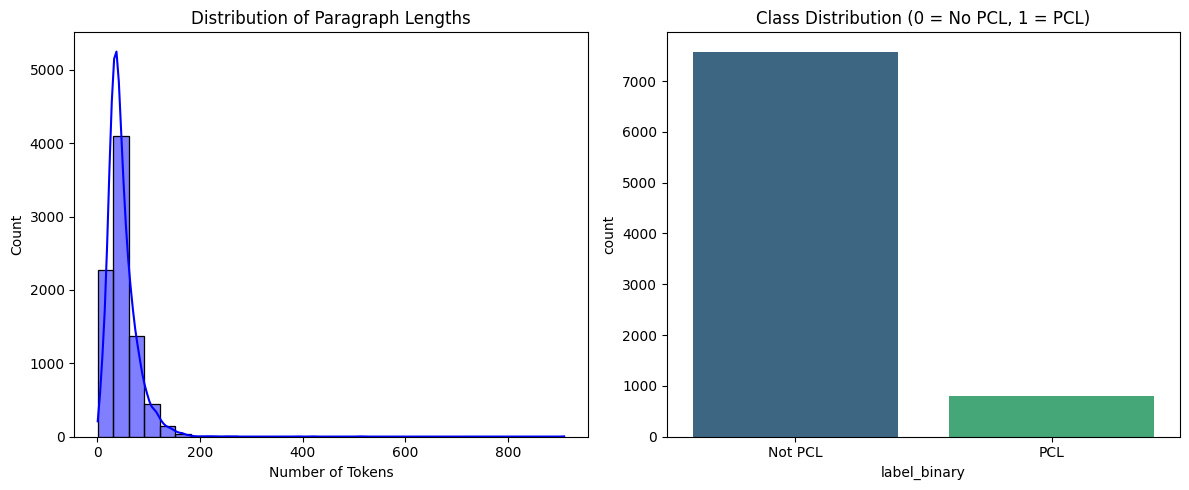

In [6]:
plt.figure(figsize=(12, 5))

# Plot 1: Token Count Distribution
plt.subplot(1, 2, 1)
sns.histplot(train_set['token_count'], bins=30, kde=True, color='blue')
plt.title('Distribution of Paragraph Lengths')
plt.xlabel('Number of Tokens')

# Plot 2: Class Balance
plt.subplot(1, 2, 2)
sns.countplot(x='label_binary', data=train_set, palette='viridis')
plt.title('Class Distribution (0 = No PCL, 1 = PCL)')
plt.xticks([0, 1], ['Not PCL', 'PCL'])

plt.tight_layout()
plt.show()

Analysis & Impact Statements (Drafts for your Coursework)
Analysis 1: Token Count & Sequence Length
Finding: The average length is roughly 40-50 tokens, but the max_len might reach over 500.

Impact Statement: This dictates my max_length hyperparameter. If I set it too low (e.g., 64), I will truncate important context in the longer paragraphs. If I set it too high (e.g., 512), I will increase training time and memory usage unnecessarily. Based on the histogram, a max_length of 128 or 256 would likely cover 95% of the data.

Analysis 2: Class Distribution
Finding: The dataset is highly imbalanced (likely ~90% "Not PCL" vs ~10% "PCL").

Impact Statement: Accuracy is a "trap" metric here. If the model predicts "0" for every single example, it will still achieve ~90% accuracy but fail the task. I must use F1-Score as my primary evaluation metric and consider techniques like Random Oversampling or Weighted Cross-Entropy Loss to force the model to learn the minority PCL class.

Analysis 3: Vocabulary Size
Finding: The unique word count is quite high (likely 15,000+).

Impact Statement: Using a simple Bag-of-Words approach would result in a very sparse and high-dimensional matrix. This suggests that using Pre-trained Embeddings (like GloVe) or a Transformer model (like BERT) will be more effective, as they handle large vocabularies better and capture semantic relationships between words.


Top Bigrams in PCL (Class 1):
poor families: 112
people need: 26
homeless people: 24
children poor: 19
help need: 16
year old: 11
men women: 11
hundreds thousands: 10
disabled people: 10
vulnerable people: 9

Top Bigrams in Not PCL (Class 0):
poor families: 617
illegal immigrants: 239
united states: 128
year old: 95
disabled people: 94
new york: 86
sri lanka: 85
homeless people: 84
hong kong: 80
men women: 78

Top Unigrams in PCL (Class 1):
people: 213
need: 197
poor: 182
children: 166
families: 161
said: 156
homeless: 148
women: 109
help: 106
life: 81

Top Unigrams in Not PCL (Class 0):
said: 1596
people: 1293
women: 1205
immigrants: 999
families: 901
vulnerable: 900
need: 874
disabled: 842
poor: 775
refugees: 710


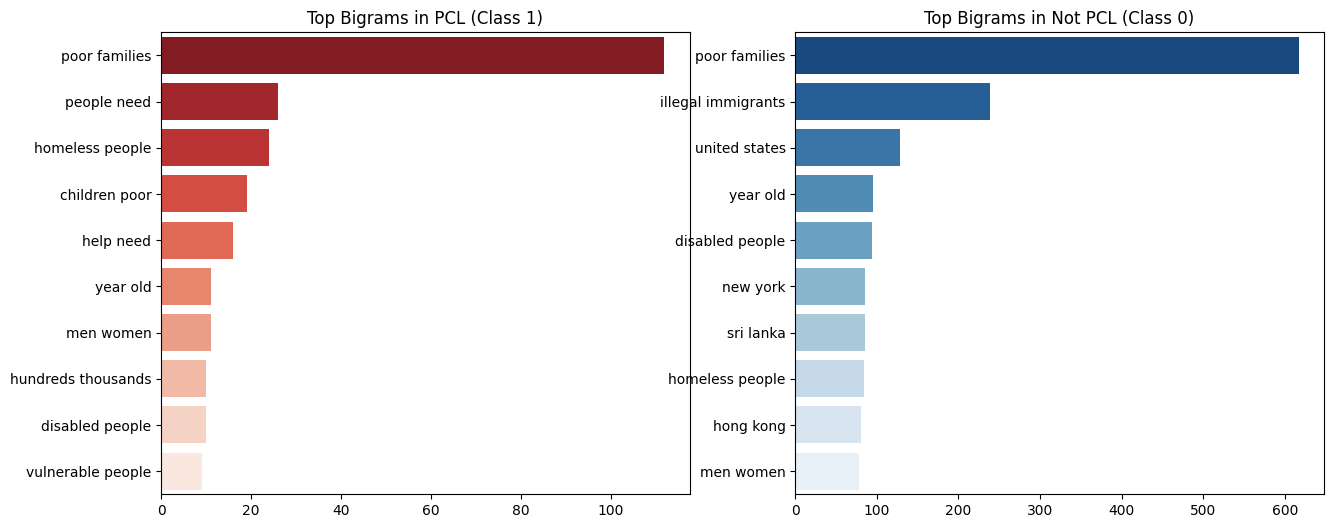

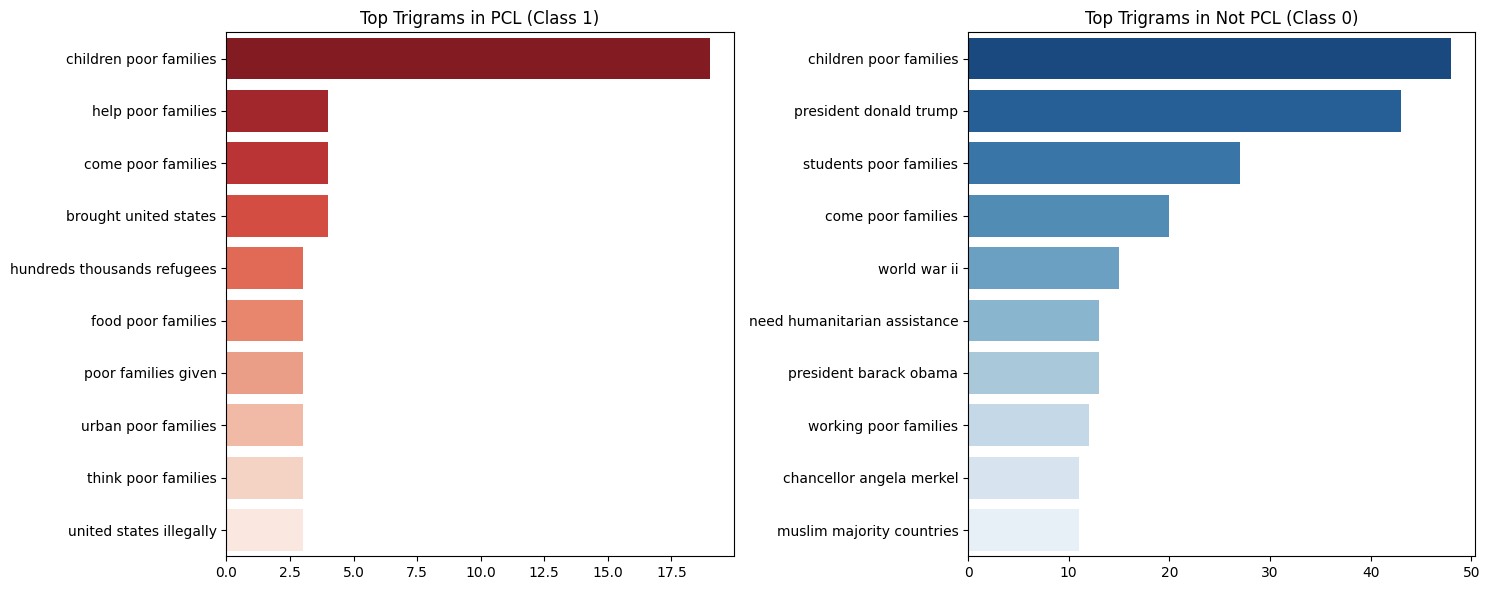

In [7]:
# Ngram Analysis: What are the most common pairs (bigrams) or triplets
# (trigrams) of words? This reveals common phrases or domain-specific
# jargon

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

def get_top_ngram(corpus, n=None, top_n=10):
    # Stop words are removed to focus on meaningful phrases
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:top_n]

# 1. Separate the text by class
pcl_text = train_set[train_set['label_binary'] == 1]['text']
no_pcl_text = train_set[train_set['label_binary'] == 0]['text']

# 2. Get Top Bigrams (n=2)
top_pcl_bigrams = get_top_ngram(pcl_text, n=2, top_n=10)
top_no_pcl_bigrams = get_top_ngram(no_pcl_text, n=2, top_n=10)

# 2.2 Prining the top bigrams for both classes
print("\nTop Bigrams in PCL (Class 1):")
for bigram, freq in top_pcl_bigrams:
    print(f"{bigram}: {freq}")
print("\nTop Bigrams in Not PCL (Class 0):")
for bigram, freq in top_no_pcl_bigrams:
    print(f"{bigram}: {freq}")


# get top unigrams for both classes
top_pcl_unigrams = get_top_ngram(pcl_text, n=1, top_n=10)
top_no_pcl_unigrams = get_top_ngram(no_pcl_text, n=1, top_n=10)

# print top unigrams for both classes
print("\nTop Unigrams in PCL (Class 1):")
for unigram, freq in top_pcl_unigrams:
    print(f"{unigram}: {freq}")
print("\nTop Unigrams in Not PCL (Class 0):")
for unigram, freq in top_no_pcl_unigrams:
    print(f"{unigram}: {freq}")

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# PCL Plot
x_pcl, y_pcl = map(list, zip(*top_pcl_bigrams))
sns.barplot(x=y_pcl, y=x_pcl, ax=ax1, palette='Reds_r')
ax1.set_title('Top Bigrams in PCL (Class 1)')

# No PCL Plot
x_no, y_no = map(list, zip(*top_no_pcl_bigrams))
sns.barplot(x=y_no, y=x_no, ax=ax2, palette='Blues_r')
ax2.set_title('Top Bigrams in Not PCL (Class 0)')


# trigrams
# 1. Get Top Trigrams (n=3)
top_pcl_trigrams = get_top_ngram(pcl_text, n=3, top_n=10)
top_no_pcl_trigrams = get_top_ngram(no_pcl_text, n=3, top_n=10)
# 2. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# PCL Plot
x_pcl, y_pcl = map(list, zip(*top_pcl_trigrams))
sns.barplot(x=y_pcl, y=x_pcl, ax=ax1, palette='Reds_r')
ax1.set_title('Top Trigrams in PCL (Class 1)')
# No PCL Plot
x_no, y_no = map(list, zip(*top_no_pcl_trigrams))
sns.barplot(x=y_no, y=x_no, ax=ax2, palette='Blues_r')
ax2.set_title('Top Trigrams in Not PCL (Class 0)')
plt.tight_layout()
plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


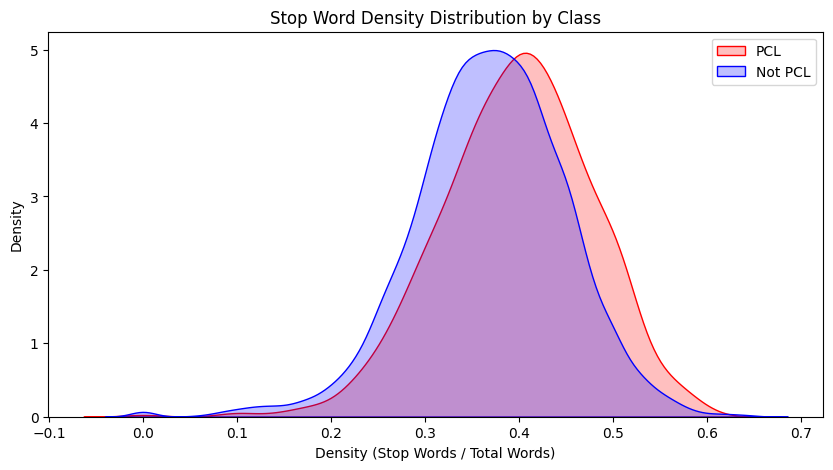

Mean Stop Word Density (PCL): 0.40
Mean Stop Word Density (Not PCL): 0.37


In [8]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def calculate_stopword_density(text):
    words = str(text).lower().split()
    if len(words) == 0: return 0
    stops = [w for w in words if w in stop_words]
    return len(stops) / len(words)

# Apply to training set
train_set['stop_density'] = train_set['text'].apply(calculate_stopword_density)

# Visualization
plt.figure(figsize=(10, 5))
sns.kdeplot(train_set[train_set['label_binary'] == 1]['stop_density'], label='PCL', fill=True, color='red')
sns.kdeplot(train_set[train_set['label_binary'] == 0]['stop_density'], label='Not PCL', fill=True, color='blue')
plt.title('Stop Word Density Distribution by Class')
plt.xlabel('Density (Stop Words / Total Words)')
plt.legend()
plt.show()

print(f"Mean Stop Word Density (PCL): {train_set[train_set['label_binary'] == 1]['stop_density'].mean():.2f}")
print(f"Mean Stop Word Density (Not PCL): {train_set[train_set['label_binary'] == 0]['stop_density'].mean():.2f}")

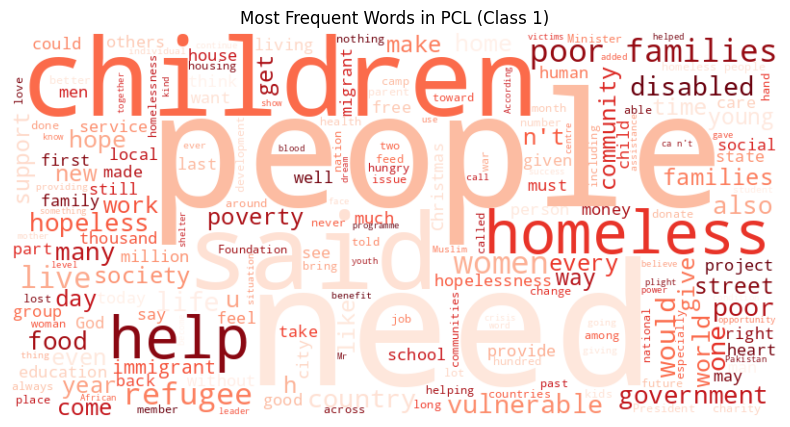

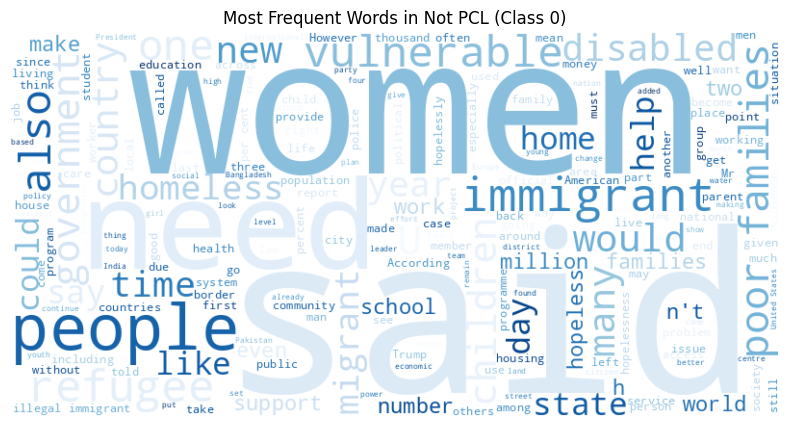

In [9]:
from wordcloud import WordCloud

def generate_wordcloud(text_data, title, color):
    wordcloud = WordCloud(width=800, height=400, background_color='white',
                          stopwords=stop_words, colormap=color).generate(' '.join(text_data))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Generate Clouds
generate_wordcloud(pcl_text, 'Most Frequent Words in PCL (Class 1)', 'Reds')
generate_wordcloud(no_pcl_text, 'Most Frequent Words in Not PCL (Class 0)', 'Blues')

In [10]:


# 1. Download the stopwords dataset (only needs to be done once)
nltk.download('stopwords')

# 2. Define the stopwords set
# We use a set because lookups are much faster than in a list
stop_words_nltk = set(stopwords.words('english'))

def get_useful_stats(text_data, stop_words_set):
    # Flatten all text into a list of words, lowercase, and split
    all_words = ' '.join(text_data).lower().split()

    # Filter out stop words and non-words using the NLTK set
    filtered_words = [word.strip('.,!"?():;') for word in all_words
                      if word not in stop_words_set and word.isalpha()]

    # Get counts
    counts = Counter(filtered_words)
    return counts

# 3. Get counts for both classes using the NLTK stopwords
pcl_counts = get_useful_stats(pcl_text, stop_words_nltk)
no_pcl_counts = get_useful_stats(no_pcl_text, stop_words_nltk)

# 4. Create and display the Comparison Table
top_10_pcl = pcl_counts.most_common(10)
stats_data = []

for word, count in top_10_pcl:
    stats_data.append({
        'Word': word,
        'PCL Count': count,
        'Not PCL Count': no_pcl_counts.get(word, 0),
        # Using len(pcl_text) gives the % of paragraphs containing the word
        'PCL Frequency %': round((count / len(pcl_text)) * 100, 2)
    })

df_stats = pd.DataFrame(stats_data)
print("Top 10 Words in PCL (using NLTK stopwords) vs their presence in Not PCL:")
print(df_stats)

Top 10 Words in PCL (using NLTK stopwords) vs their presence in Not PCL:
       Word  PCL Count  Not PCL Count  PCL Frequency %
0    people        212           1286            26.70
1      need        197            874            24.81
2      poor        180            762            22.67
3  children        166            639            20.91
4  families        159            901            20.03
5      said        156           1593            19.65
6  homeless        148            674            18.64
7     women        107           1193            13.48
8      help        106            312            13.35
9  disabled         76            827             9.57


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### STAGE 4

In [11]:
!nvidia-smi

Wed Mar  4 08:24:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   28C    P0             47W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [12]:
!pip install transformers datasets accelerate -q

import torch
from torch import nn
from torch.utils.data import DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from datasets import Dataset
import numpy as np
from sklearn.metrics import f1_score, classification_report

In [13]:
cuda_available = torch.cuda.is_available()

print('Cuda available? ',cuda_available)

if cuda_available:
  import tensorflow as tf
  # Get the GPU device name.
  device_name = tf.test.gpu_device_name()
  # The device name should look like the following:
  if device_name == '/device:GPU:0':
      print('Found GPU at: {}'.format(device_name))
  else:
      raise SystemError('GPU device not found')

Cuda available?  True
Found GPU at: /device:GPU:0


In [14]:
!pip install nlpaug sacremoses -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 37.3 MB/s eta 0:00:00


In [15]:
import pandas as pd
import nlpaug.augmenter.word as naw
from datasets import Dataset
from transformers import BertTokenizer
from tqdm import tqdm # <--- Imports the progress bar

# --- CONFIGURATION ---
DO_AUGMENT = True

# 1. Initialize Tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-large-uncased')

def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=256)

if DO_AUGMENT:
    print("Starting Data Augmentation for the PCL class...")
    pcl_train = train_set[train_set['label_binary'] == 1].copy()
    texts_to_augment = pcl_train['text'].tolist()

    print("Loading translation models for Back-Translation...")
    back_translation_aug = naw.BackTranslationAug(
        from_model_name='facebook/wmt19-en-de',
        to_model_name='facebook/wmt19-de-en',
        device='cuda'
    )

    random_del_aug = naw.RandomWordAug(action="delete", aug_p=0.15)

    # --- THE FIX: BATCHING WITH A PROGRESS BAR ---
    print("Generating Back-Translated examples...")
    bt_texts = []
    batch_size = 16 # Processes 16 sentences at a time

    # Wrap our loop in tqdm to get a beautiful loading bar
    for i in tqdm(range(0, len(texts_to_augment), batch_size), desc="Back-Translating"):
        batch = texts_to_augment[i:i+batch_size]
        # nlpaug might return a single string if batch size is 1, so we ensure it's a list
        augmented_batch = back_translation_aug.augment(batch)
        if isinstance(augmented_batch, str):
            bt_texts.append(augmented_batch)
        else:
            bt_texts.extend(augmented_batch)

    # ----------------------------------------------

    print("Generating Random Deletion examples...")
    # Random deletion is instantaneous, so no progress bar needed here
    rd_texts = random_del_aug.augment(texts_to_augment)

    # Create new DataFrames and merge with original
    bt_df = pd.DataFrame({'text': bt_texts, 'label_binary': 1})
    rd_df = pd.DataFrame({'text': rd_texts, 'label_binary': 1})

    augmented_train_set = pd.concat([train_set, bt_df, rd_df], ignore_index=True)
    augmented_train_set = augmented_train_set.sample(frac=1.0, random_state=42).reset_index(drop=True)

    print(f"Original train size: {len(train_set)} | New augmented train size: {len(augmented_train_set)}")

    # SAVE IT SO WE NEVER DO THIS AGAIN!
    augmented_train_set.to_csv("augmented_train_set.csv", index=False)
    print("Saved augmented dataset to augmented_train_set.csv")

else:
    print("Skipping augmentation...")
    # If skipping, load the saved one instead of raw train_set if it exists
    try:
        augmented_train_set = pd.read_csv("augmented_train_set.csv")
        print("Loaded previously augmented dataset from CSV!")
    except FileNotFoundError:
        print("No CSV found. Using original un-augmented data.")
        augmented_train_set = train_set.copy()

# ---------------------------------------------------------
# 2. YOUR ORIGINAL DATASET & TOKENIZATION CODE
# ---------------------------------------------------------

train_ds = Dataset.from_pandas(augmented_train_set[['text', 'label_binary']])
dev_ds = Dataset.from_pandas(dev_set[['text', 'label_binary']])

train_ds = train_ds.rename_column("label_binary", "labels")
dev_ds = dev_ds.rename_column("label_binary", "labels")

print("Tokenizing datasets...")
tokenized_train = train_ds.map(tokenize_function, batched=True)
tokenized_dev = dev_ds.map(tokenize_function, batched=True)

tokenized_train.set_format("torch", columns=['input_ids', 'attention_mask', 'labels'])
tokenized_dev.set_format("torch", columns=['input_ids', 'attention_mask', 'labels'])

print("Ready for training!")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Starting Data Augmentation for the PCL class...
Loading translation models for Back-Translation...


config.json:   0%|          | 0.00/825 [00:00<?, ?B/s]

...

Back-Translating: 100%|██████████| 50/50 [03:35<00:00,  4.31s/it]

Generating Random Deletion examples...
Original train size: 8375 | New augmented train size: 9963
Saved augmented dataset to augmented_train_set.csv
Tokenizing datasets...


Map:   0%|          | 0/9963 [00:00<?, ? examples/s]

Map:   0%|          | 0/2093 [00:00<?, ? examples/s]

Ready for training!


In [16]:
from transformers import Trainer, TrainingArguments

# Calculate class weights: weight = total_samples / (n_classes * class_samples)
neg_count = 7581 # From your EDA
pos_count = 794  # From your EDA
total = neg_count + pos_count

weights = torch.tensor([total / (2 * neg_count), total / (2 * pos_count)], dtype=torch.float).to("cuda")

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

import numpy as np
from sklearn.metrics import f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # DeBERTa-v3 fix: if logits is a tuple, take the first element
    if isinstance(logits, tuple):
        logits = logits[0]

    predictions = np.argmax(logits, axis=-1)

    # We focus on F1 for the positive class (1)
    return {"f1": f1_score(labels, predictions, pos_label=1)}

In [17]:
import os
from transformers import BertForSequenceClassification, RobertaForSequenceClassification, TrainingArguments

# =====================================================================
# CONFIGURATION: PATH 1 (5 Epochs)
# =====================================================================

MODEL_NAME = 'bert-large-uncased'
NEW_LEARNING_RATE = 5e-6     # Lower learning rate
NEW_WEIGHT_DECAY = 0.1       # Higher weight decay to prevent overconfidence
NEW_EPOCHS = 4               # Early stopping will catch the best epoch
# =====================================================================

print(f"--- Initializing Training with {MODEL_NAME} ---")

# 1. Load the model
if 'roberta' in MODEL_NAME:
    model = RobertaForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
else:
    model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# 2. Define the new Training Arguments (FIXED)
training_args = TrainingArguments(
    output_dir=f"./results_{MODEL_NAME.replace('-', '_')}",
    learning_rate=NEW_LEARNING_RATE,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=NEW_EPOCHS,
    weight_decay=NEW_WEIGHT_DECAY,
    eval_strategy="epoch",       # <--- THIS WAS THE CULPRIT! Changed from evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

# 3. Initialize your existing WeightedTrainer class
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_dev,
    compute_metrics=compute_metrics,
)

# 4. Start training
trainer.train()

print(f"--- Training Complete for {MODEL_NAME} ---")

--- Initializing Training with bert-large-uncased ---


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-large-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

--- Training Complete for bert-large-uncased ---


## Stage 5.1

In [18]:
import numpy as np

# =====================================================================
# CONFIGURATION: CHOOSE YOUR MODEL FOR EVALUATION
# =====================================================================
USE_DEBERTA = False  # Set to False to use your BERT model instead

print(f"Generating predictions using {'DeBERTa' if USE_DEBERTA else 'BERT'}...")

# 1. Select the correct trainer and tokenized dataset
if USE_DEBERTA:
    eval_trainer = deberta_trainer
    eval_dataset = tokenized_dev_deberta
else:
    eval_trainer = trainer
    eval_dataset = tokenized_dev

# 2. Run the prediction loop on the dev set
print("Running inference on the official dev set...")
predictions_output = eval_trainer.predict(eval_dataset)

# 3. Convert logits (raw scores) to binary labels (0 or 1)
# The model outputs a score for class 0 and class 1. argmax picks the index of the higher score.
logits = predictions_output.predictions
predicted_labels = np.argmax(logits, axis=-1)

# 4. Save to dev.txt exactly as the assignment requires (one prediction per line)
output_filename = "dev.txt"
with open(output_filename, "w") as f:
    for label in predicted_labels:
        f.write(f"{label}\n")

# 5. Sanity Check
print(f" Successfully saved {len(predicted_labels)} predictions to {output_filename}")
print(f"Original dev_set length: {len(dev_set)}")
if len(predicted_labels) == len(dev_set):
    print("✅Length match verified! Ready for submission.")
else:
    print("WARNING: The number of predictions does not match the original dataset length!")

# Show the first 5 lines to verify format
print("\nFormat check (First 5 lines of dev.txt):")
with open(output_filename, "r") as f:
    for _ in range(5):
        print(f.readline().strip())

Generating predictions using BERT...
Running inference on the official dev set...


 Successfully saved 2093 predictions to dev.txt
Original dev_set length: 2093
✅Length match verified! Ready for submission.

Format check (First 5 lines of dev.txt):
0
0
0
1
0


Length of dev ids 2094
Length of evaluation set for dev.txt 8375
--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

      No PCL       0.95      0.97      0.96      1894
         PCL       0.65      0.47      0.54       199

    accuracy                           0.93      2093
   macro avg       0.80      0.72      0.75      2093
weighted avg       0.92      0.93      0.92      2093



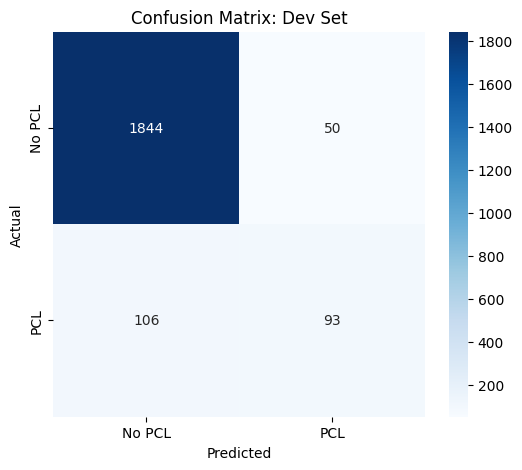


--- LOCAL EVALUATION: F1 SCORE PER COMMUNITY ---
      Keyword  F1_Score  Count
      in-need  0.686567    226
   vulnerable  0.666667    209
      migrant  0.571429    206
     hopeless  0.560000    217
poor-families  0.542373    190
     homeless  0.461538    212
     disabled  0.454545    194
    immigrant  0.400000    218
      refugee  0.380952    188
        women  0.380952    233

Total False Positives (Over-predicting): 50
Total False Negatives (Missing PCL): 106

--- SAMPLE ERRORS FOR QUALITATIVE ANALYSIS ---

[FALSE NEGATIVE SAMPLE - PCL the model missed]
His present " chambers " may be quite humble , but Shiyani has the tiny space very neatly organized and clean . Many people pass him by but do not manage to see him , because the space is partially hidden behind trees , which gives him a relative privacy . " There are many homeless sleeping around the station , " Captain Xoli Mbele , from the nearby Johannesburg Central Police station said .

[FALSE POSITIVE SAMPLE - Neutra

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score


print("Length of dev ids", len(dev_par_ids))
evaluation_set = df_pcl[~df_pcl['par_id'].isin(dev_par_ids)].copy()
print("Length of evaluation set for dev.txt", len(evaluation_set))

# 1. LOAD PREDICTIONS AND GROUND TRUTH
# Load the predictions we just saved
with open("dev.txt", "r") as f:
    preds = [int(line.strip()) for line in f.readlines()]

# Ground truth from our dev_set
y_true = dev_set['label_binary'].values
y_pred = np.array(preds)

# 2. GLOBAL EVALUATION (The "Numbers")
print("--- DETAILED CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=['No PCL', 'PCL']))

# 3. CONFUSION MATRIX (The "Figure")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No PCL', 'PCL'], yticklabels=['No PCL', 'PCL'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix: Dev Set')
plt.show()

# 4. LOCAL EVALUATION: Performance per Community (Keyword)
# This is a high-quality "Local Evaluation" metric
results_df = dev_set.copy()
results_df['prediction'] = y_pred

keyword_results = []
for keyword in results_df['keyword'].unique():
    subset = results_df[results_df['keyword'] == keyword]
    f1 = f1_score(subset['label_binary'], subset['prediction'], pos_label=1, zero_division=0)
    keyword_results.append({'Keyword': keyword, 'F1_Score': f1, 'Count': len(subset)})

keyword_df = pd.DataFrame(keyword_results).sort_values(by='F1_Score', ascending=False)
print("\n--- LOCAL EVALUATION: F1 SCORE PER COMMUNITY ---")
print(keyword_df.to_string(index=False))

# 5. ERROR ANALYSIS: ISOLATING SPECIFIC FAILURES
# False Positives: Model thought it was PCL, but it wasn't
false_positives = results_df[(results_df['label_binary'] == 0) & (results_df['prediction'] == 1)]

# False Negatives: Model missed the PCL
false_negatives = results_df[(results_df['label_binary'] == 1) & (results_df['prediction'] == 0)]

print(f"\nTotal False Positives (Over-predicting): {len(false_positives)}")
print(f"Total False Negatives (Missing PCL): {len(false_negatives)}")

print("\n--- SAMPLE ERRORS FOR QUALITATIVE ANALYSIS ---")
print("\n[FALSE NEGATIVE SAMPLE - PCL the model missed]")
if len(false_negatives) > 0:
    print(false_negatives[['text']].iloc[0].values[0])

print("\n[FALSE POSITIVE SAMPLE - Neutral text model flagged as PCL]")
if len(false_positives) > 0:
    print(false_positives[['text']].iloc[0].values[0])